EE 344 Final Project - Data Preprocessing

In [1]:
from google.colab import drive
import numpy as np
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import pandas as pd
import glob
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

#------------------------------
# Load data & test train split
#------------------------------

# File paths
file1 = "/content/drive/MyDrive/Junior Year/EE 344/Final Project Data/2014.csv.zip"
file2 = "/content/drive/MyDrive/Junior Year/EE 344/Final Project Data/2015.csv.zip"

# Columns to keep
columns_to_keep = [
    'FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DEST', 'CRS_DEP_TIME',
    'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'CANCELLED',
    'CANCELLATION_CODE', 'DIVERTED', 'DEP_DELAY'
]

# Define smaller dtypes to save memory
dtypes = {
    'OP_CARRIER': 'category',
    'ORIGIN': 'category',
    'DEST': 'category',
    'CRS_DEP_TIME': 'int32',
    'CRS_ARR_TIME': 'int32',
    'CRS_ELAPSED_TIME': 'float32',
    'DISTANCE': 'float32',
    'CANCELLED': 'int8',
    'DIVERTED': 'int8',
    'DEP_DELAY': 'float32',
    'CANCELLATION_CODE': 'category'
}

# Read CSV files with selected columns and dtypes
df1 = pd.read_csv(file1, usecols=columns_to_keep, dtype=dtypes)
df2 = pd.read_csv(file2, usecols=columns_to_keep, dtype=dtypes)

# Combine into one DataFrame
all_data = pd.concat([df1, df2], ignore_index=True)

# Free memory from intermediate DataFrames
del df1, df2

# Convert date column to datetime
all_data.loc[:, 'FL_DATE'] = pd.to_datetime(all_data['FL_DATE'])

# Remove cancelled/diverted flights to reduce size
all_data = all_data[(all_data['CANCELLED'] == 0) & (all_data['DIVERTED'] == 0)].copy()

# Sort chronologically
all_data = all_data.sort_values("FL_DATE").reset_index(drop=True)

# 70/30 chronological train/test split
split_index = int(len(all_data) * 0.7)
train_df = all_data.iloc[:split_index].copy()
test_df  = all_data.iloc[split_index:].copy()

# Check date ranges
print(train_df["FL_DATE"].min(), "to", train_df["FL_DATE"].max())
print(test_df["FL_DATE"].min(), "to", test_df["FL_DATE"].max())

2014-01-01 00:00:00 to 2015-05-29 00:00:00
2015-05-29 00:00:00 to 2015-12-31 00:00:00


In [4]:


# ------------------------
# Preprocessing Pipeline
# ------------------------
# Used for all models. Depending on model needs, only certain columns will be chosen for each model's data.

def preprocess_flight_data(df):
    df = df.copy()

    # Ensure FL_DATE is datetime
    df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

    # Extract basic time features from CRS_DEP_TIME
    df['CRS_DEP_TIME'] = df['CRS_DEP_TIME'].fillna(0).astype(int)
    df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100  # 0-23 hour
    df['DEP_MIN'] = df['CRS_DEP_TIME'] % 100    # minutes if needed
    df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek  # Monday=0, Sunday=6
    df['MONTH'] = df['FL_DATE'].dt.month

    # Time-of-day label
    def get_time_of_day(hour):
        if 5 <= hour < 12:
            return 'morning'
        elif 12 <= hour < 17:
            return 'afternoon'
        elif 17 <= hour < 21:
            return 'evening'
        else:
            return 'night'
    df['TIME_OF_DAY'] = df['DEP_HOUR'].apply(get_time_of_day)

    # Holiday flag using USFederalHolidayCalendar
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df['FL_DATE'].min(), end=df['FL_DATE' ].max())
    df['IS_HOLIDAY'] = df['FL_DATE'].isin(holidays).astype(int)

    # Cyclic encoding placeholders (for linear models)
    df['DEP_HOUR_SIN'] = np.sin(2 * np.pi * df['DEP_HOUR']/24)
    df['DEP_HOUR_COS'] = np.cos(2 * np.pi * df['DEP_HOUR']/24)
    df['DAY_OF_WEEK_SIN'] = np.sin(2 * np.pi * df['DAY_OF_WEEK']/7)
    df['DAY_OF_WEEK_COS'] = np.cos(2 * np.pi * df['DAY_OF_WEEK']/7)

    return df

# Apply preprocessing to all data.
train_data = preprocess_flight_data(train_df)
test_data = preprocess_flight_data(test_df)

print(train_data.head())

     FL_DATE OP_CARRIER ORIGIN DEST  CRS_DEP_TIME  DEP_DELAY  CRS_ARR_TIME  \
0 2014-01-01         AA    ICT  DFW          1135        9.0          1300   
1 2014-01-01         UA    SAN  SFO          1122       18.0          1257   
2 2014-01-01         UA    SFO  LAX          1631       -7.0          1804   
3 2014-01-01         UA    IAH  LAX          1318       25.0          1514   
4 2014-01-01         UA    AUS  DEN           751       -4.0           906   

   CANCELLED CANCELLATION_CODE  DIVERTED  ...  DEP_HOUR  DEP_MIN  DAY_OF_WEEK  \
0          0               NaN         0  ...        11       35            2   
1          0               NaN         0  ...        11       22            2   
2          0               NaN         0  ...        16       31            2   
3          0               NaN         0  ...        13       18            2   
4          0               NaN         0  ...         7       51            2   

   MONTH  TIME_OF_DAY  IS_HOLIDAY DEP_HOUR_S

In [5]:
def prepare_model_data(df, approach='binary', model_type='linear', ohe=None, scaler=None):
    df = df.copy()

    if approach == 'binary':
        y = (df['DEP_DELAY'] > 15).astype(int)
    elif approach == 'regression':
        y = df['DEP_DELAY'].astype(float)
    elif approach == 'regression_log':
        y = np.log1p(df['DEP_DELAY'].clip(lower=0).astype(float))
    elif approach == 'multiclass':
        bins = [0, 15, 30, 60, np.inf]
        labels = [0, 1, 2, 3]
        y = pd.cut(df['DEP_DELAY'], bins=bins, labels=labels, right=True).astype(int)
    else:
        raise ValueError("Approach must be 'binary', 'regression', or 'multiclass'")

    if model_type == 'linear':
        categorical_cols = ['OP_CARRIER', 'ORIGIN', 'DEST', 'MONTH', 'DAY_OF_WEEK']
        numeric_cols = ['DISTANCE', 'CRS_ELAPSED_TIME',
                        'DEP_HOUR_SIN', 'DEP_HOUR_COS',
                        'DAY_OF_WEEK_SIN', 'DAY_OF_WEEK_COS']

        if ohe is None:
            ohe = OneHotEncoder(drop='first', sparse_output=True, handle_unknown='ignore')
            X_cat_sparse = ohe.fit_transform(df[categorical_cols])
        else:
            X_cat_sparse = ohe.transform(df[categorical_cols])

        if scaler is None:
            scaler = StandardScaler()
            X_num_scaled = scaler.fit_transform(df[numeric_cols])
        else:
            X_num_scaled = scaler.transform(df[numeric_cols])

        from scipy.sparse import hstack, csr_matrix
        X = hstack([csr_matrix(X_num_scaled), X_cat_sparse], format='csr')
        return X, y, ohe, scaler

    elif model_type == 'tree':
        tree_categorical_cols = ['OP_CARRIER', 'ORIGIN', 'DEST', 'MONTH', 'DAY_OF_WEEK', 'TIME_OF_DAY']
        tree_numeric_cols = ['DISTANCE', 'CRS_ELAPSED_TIME']

        X_cat = df[tree_categorical_cols].apply(lambda x: x.astype('category').cat.codes)
        X_num = df[tree_numeric_cols]
        X = pd.concat([X_num, X_cat], axis=1)
        return X, y, None, None

# **Linear Regression Model**

In [6]:
X_train_linear_reg, y_train_reg, ohe_reg, scaler_reg = prepare_model_data(
    train_data, approach='regression', model_type='linear'
)
X_test_linear_reg, y_test_reg, _, _ = prepare_model_data(
    test_data, approach='regression', model_type='linear', ohe=ohe_reg, scaler=scaler_reg
)

In [7]:
# Predict mean delay from training set
baseline_prediction = np.full_like(y_test_reg, y_train_reg.mean())

rmse_baseline = np.sqrt(mean_squared_error(y_test_reg, baseline_prediction))
mae_baseline = mean_absolute_error(y_test_reg, baseline_prediction)
r2_baseline = r2_score(y_test_reg, baseline_prediction)

print("Baseline RMSE:", rmse_baseline)
print("Baseline MAE:", mae_baseline)
print("Baseline R^2:", r2_baseline)

Baseline RMSE: 36.97828324207754
Baseline MAE: 19.211954598462324
Baseline R^2: -0.0008852773604042241


In [8]:
linear_model = LinearRegression()
linear_model.fit(X_train_linear_reg, y_train_reg)

y_pred_lr = linear_model.predict(X_test_linear_reg)

rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)
print("Linear Regression R^2:", r2_lr)

Linear Regression RMSE: 36.459943451571064
Linear Regression MAE: 18.51038724658759
Linear Regression R^2: 0.02697770127412391


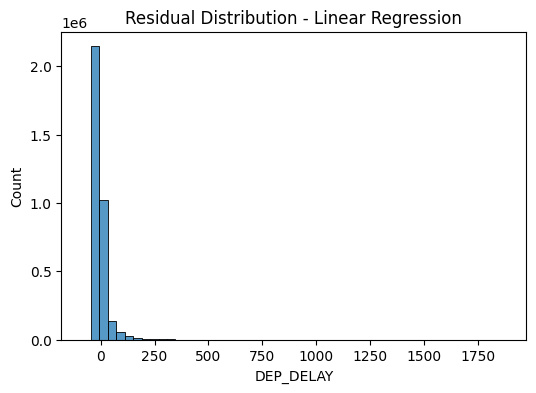

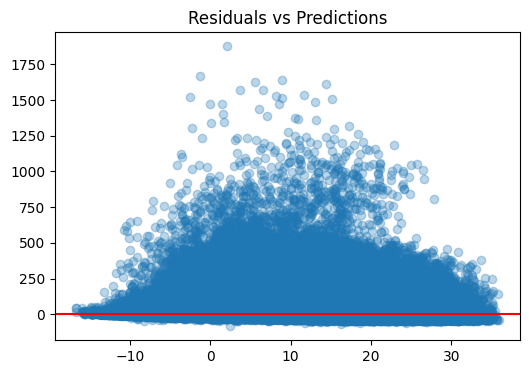

In [9]:
residuals = y_test_reg - y_pred_lr

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=50)
plt.title("Residual Distribution - Linear Regression")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions")
plt.show()

In [10]:
# bottom of Cell 8, after you have y_pred_lr
##import gc
##del X_train_linear_reg, X_test_linear_reg, ohe_reg, scaler_reg
##gc.collect()

# **Tree Regression Model**

In [11]:
X_train_tree_reg, y_train_reg_tree, _, _ = prepare_model_data(train_data, approach='regression', model_type='tree')
X_test_tree_reg, y_test_reg_tree, _, _ = prepare_model_data(test_data, approach='regression', model_type='tree')

In [12]:


rf_model = RandomForestRegressor(
    n_estimators=50,    # down from 100
    max_depth=10,       # down from 15
    max_samples=0.5,    # train each tree on 50% of data
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tree_reg, y_train_reg_tree)

y_pred_rf = rf_model.predict(X_test_tree_reg)

rmse_rf = np.sqrt(mean_squared_error(y_test_reg_tree, y_pred_rf))
mae_rf = mean_absolute_error(y_test_reg_tree, y_pred_rf)
r2_rf = r2_score(y_test_reg_tree, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)
print("Random Forest R^2:", r2_rf)

Random Forest RMSE: 36.80750956786492
Random Forest MAE: 18.3998740891776
Random Forest R^2: 0.008337983290652384


In [13]:
from lightgbm import LGBMRegressor

gb_model = LGBMRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

gb_model.fit(X_train_tree_reg, y_train_reg_tree)

y_pred_gb = gb_model.predict(X_test_tree_reg)

rmse_gb = np.sqrt(mean_squared_error(y_test_reg_tree, y_pred_gb))
mae_gb = mean_absolute_error(y_test_reg_tree, y_pred_gb)
r2_gb = r2_score(y_test_reg_tree, y_pred_gb)

print("LightGBM RMSE:", rmse_gb)
print("LightGBM MAE:", mae_gb)
print("LightGBM R^2:", r2_gb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.191074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 941
[LightGBM] [Info] Number of data points in the train set: 7974670, number of used features: 8
[LightGBM] [Info] Start training from score 10.262116
LightGBM RMSE: 36.85207703519903
LightGBM MAE: 18.186712487976713
LightGBM R^2: 0.005935070309418755


In [14]:
##del X_train_tree_reg, X_test_tree_reg
##gc.collect()

In [15]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

cv_scores_lr = cross_val_score(
    linear_model,
    X_train_linear_reg,
    y_train_reg,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)
print("Linear Regression CV RMSE:", -cv_scores_lr.mean())

cv_scores_rf = cross_val_score(
    rf_model,
    X_train_tree_reg,
    y_train_reg_tree,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)
print("Random Forest CV RMSE:", -cv_scores_rf.mean())

Linear Regression CV RMSE: 36.00641700584704
Random Forest CV RMSE: 35.946630516888185


In [16]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse_baseline, rmse_lr, rmse_rf, rmse_gb],
    "MAE": [mae_baseline, mae_lr, mae_rf, mae_gb],
    "R^2": [r2_baseline, r2_lr, r2_rf, r2_gb]
})

print(results)

               Model       RMSE        MAE       R^2
0           Baseline  36.978283  19.211955 -0.000885
1  Linear Regression  36.459943  18.510387  0.026978
2      Random Forest  36.807510  18.399874  0.008338
3  Gradient Boosting  36.852077  18.186712  0.005935


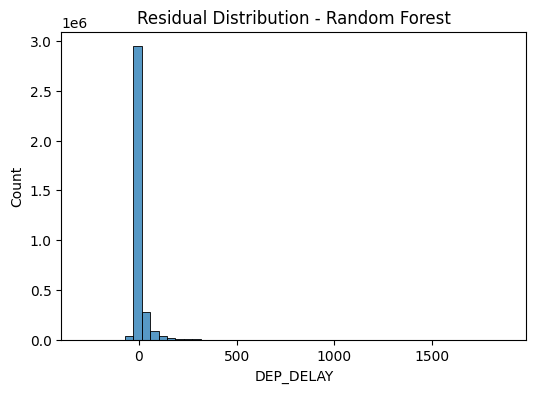

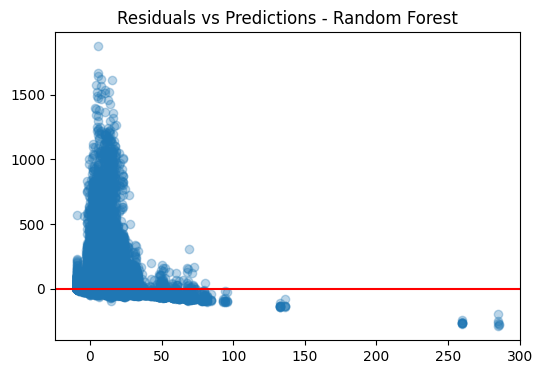

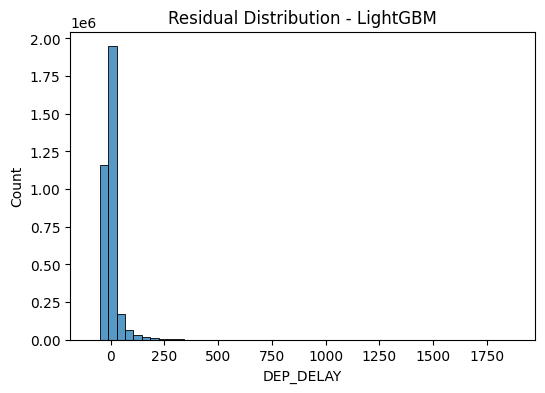

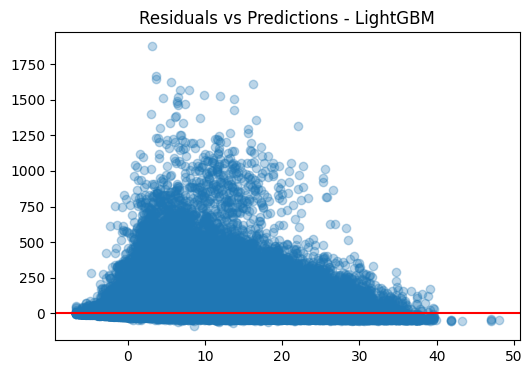

In [17]:
residuals_rf = y_test_reg_tree - y_pred_rf

plt.figure(figsize=(6,4))
sns.histplot(residuals_rf, bins=50)
plt.title("Residual Distribution - Random Forest")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions - Random Forest")
plt.show()

residuals_gb = y_test_reg_tree - y_pred_gb

plt.figure(figsize=(6,4))
sns.histplot(residuals_gb, bins=50)
plt.title("Residual Distribution - LightGBM")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred_gb, residuals_gb, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions - LightGBM")
plt.show()

All R² values are near 0, meaning the models explain almost none of the variance in delay. Baseline R² of -0.0009 is essentially 0, and your best model (Linear Regression) only reaches 0.027

Linear Regression barely beats the baseline (RMSE 36.46 vs 36.98), which is surprising — you'd expect tree models to do better

Random Forest and Gradient Boosting actually perform worse than Linear Regression, which suggests the features available aren't capturing what drives delays

**Why this might be happening**

Flight delay is heavily driven by factors you don't have — weather, air traffic control, aircraft/crew status, upstream delays. Your features (carrier, origin, dest, time of day, distance) have weak predictive power for the actual delay amount

Predicting the magnitude of delay is much harder than predicting whether a flight will be delayed (your binary model likely performs better)

Extremely right-skewed — most residuals cluster near 0 but there's a long tail stretching to 1800+ minutes

This means the model handles on-time flights okay but completely fails on severely delayed flights

The extreme outliers (500+ min delays) are likely tanking your RMSE

# **Log-Transformed Delay**

In [6]:

# Prepare data with log-transformed target
# Add 1 to handle zero delays (log(0) is undefined)
train_data['DEP_DELAY_LOG'] = np.log1p(train_data['DEP_DELAY'].clip(lower=0))
test_data['DEP_DELAY_LOG'] = np.log1p(test_data['DEP_DELAY'].clip(lower=0))

In [7]:
X_train_linear_log, y_train_log, ohe_log, scaler_log = prepare_model_data(
    train_data, approach='regression_log', model_type='linear'
)
X_test_linear_log, y_test_log, _, _ = prepare_model_data(
    test_data, approach='regression_log', model_type='linear', ohe=ohe_log, scaler=scaler_log
)

linear_model_log = LinearRegression()
linear_model_log.fit(X_train_linear_log, y_train_log)
y_pred_log = linear_model_log.predict(X_test_linear_log)

# Convert predictions back to original scale for interpretable metrics
y_pred_log_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test_log)

rmse_log = np.sqrt(mean_squared_error(y_test_orig, y_pred_log_orig))
mae_log = mean_absolute_error(y_test_orig, y_pred_log_orig)
r2_log = r2_score(y_test_orig, y_pred_log_orig)

print("Log-transformed Linear Regression RMSE:", rmse_log)
print("Log-transformed Linear Regression MAE:", mae_log)
print("Log-transformed Linear Regression R^2:", r2_log)

Log-transformed Linear Regression RMSE: 36.92385164308641
Log-transformed Linear Regression MAE: 12.302129029838698
Log-transformed Linear Regression R^2: -0.05674836529202554


The RMSE got worse but MAE improved significantly (18.5 → 12.3)

The log transform made the model more conservative — it stopped trying to predict large delays and instead predicted closer to the median, which lowered MAE

But the extreme delays it now underpredicts are hurting RMSE even more, since those large errors get squared

The negative R² means it's actually worse than just predicting the mean on the original scale

The log transformation improves MAE but worsens RMSE, suggesting it shifts the model toward predicting typical delays more accurately at the cost of handling outliers even worse. Neither transformation produces a strong model, reinforcing that the available features have limited predictive power for delay magnitude regardless of how the target is scaled.

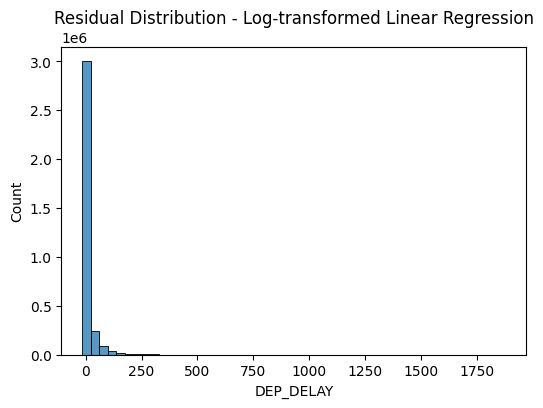

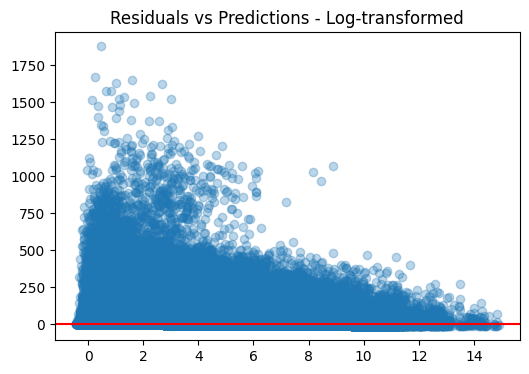

In [8]:
residuals_log = y_test_orig - y_pred_log_orig

plt.figure(figsize=(6,4))
sns.histplot(residuals_log, bins=50)
plt.title("Residual Distribution - Log-transformed Linear Regression")
plt.xlabel("DEP_DELAY")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred_log_orig, residuals_log, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions - Log-transformed")
plt.show()

The distribution is tighter than the original (most residuals now under 250 vs 1800+), which explains the improved MAE

But still heavily right-skewed — the log transform compressed the tail but didn't eliminate it


The log transformation shifted the bias but didn't solve the fundamental problem — the model can't capture what actually causes large delays. The two residual plots together make a compelling visual argument that schedule-based features alone are insufficient for regression regardless of target scaling.

**Overall Conclusion**

The core finding is that flight delay magnitude cannot be reliably predicted from schedule-based features alone. Across all models, R² hovers near 0, meaning none of them explain the variance in delays meaningfully better than just predicting the mean.
Specific takeaways:

All four models (baseline, linear, random forest, LightGBM) perform nearly identically in RMSE (~36-37 min), which suggests the features — not the model complexity — are the limiting factor. Adding more sophisticated models didn't help.

The log transformation improved MAE (18.5 → 12.3) but worsened R², showing a tradeoff between handling typical delays vs. extreme ones, not an overall improvement

The residual plots show persistent heteroscedasticity regardless of transformation, confirming the model systematically fails on large delays

The fact that Random Forest and LightGBM didn't outperform Linear Regression is telling — tree models usually dominate on tabular data, so when they don't, it strongly points to missing features